# 05 — Softmax Selection

**Goal:** Convert adjusted template scores into a **probability distribution** using softmax, and select templates by sampling.

This notebook covers:
- The exploration vs exploitation dilemma
- The softmax (Boltzmann) formula
- How the temperature parameter τ controls the balance
- A full single-event walkthrough: scores → recency → softmax → selection

## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

# For loading a small sample for the worked example only
import src.data_loader as _dl
_dl.USE_FULL_DATA = False

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_sample, parse_history, parse_eligible_templates
from src.recency.recency_penalty import adjust_scores_with_recency
from src.bandit.softmax_selector import (
    softmax_probabilities,
    softmax_select,
    explain_softmax_selection,
)

sns.set_style("whitegrid")

INTERMEDIATE_DIR = os.path.join("..", "data", "intermediate")

print("Ready!")

Ready!


---
## 1. Load Smoothed Scores from Notebook 04 (Full Data)

These scores were computed from all ~88M training rows via chunked processing.

In [2]:
with open(os.path.join(INTERMEDIATE_DIR, "04_results.json")) as f:
    prev = json.load(f)

smoothed_scores = prev["smoothed_scores"]
templates = sorted(smoothed_scores.keys())

print(f"Loaded smoothed scores from full data ({prev['total_rows']:,} rows)")
for t in templates:
    print(f"  Template {t}: smoothed = {smoothed_scores[t]:+.6f}")

Loaded smoothed scores from full data (87,665,839 rows)
  Template A: smoothed = +0.124412
  Template B: smoothed = -0.006921
  Template C: smoothed = +0.000000
  Template D: smoothed = -0.004490
  Template E: smoothed = -0.005923
  Template F: smoothed = -0.006545
  Template G: smoothed = -0.003868
  Template H: smoothed = -0.006920
  Template J: smoothed = -0.005097
  Template K: smoothed = -0.004072
  Template L: smoothed = -0.003776


---
## 2. The Exploration-Exploitation Dilemma

After scoring, the simplest strategy is **greedy**: always pick the highest-scoring template. But this has a problem:

- What if our scores are slightly wrong?
- What if a template we've barely tried is actually the best?
- We'd never discover it because we keep picking the current leader.

The solution: assign **probabilities** to each template based on scores, then **sample**. Good templates are more likely, but others still get tried occasionally.

---
## 3. The Softmax Formula

$$P(a) = \frac{e^{\tau \times \text{score}(a)}}{\sum_{t \in \text{eligible}} e^{\tau \times \text{score}(t)}}$$

The **temperature parameter τ** controls the balance:

| τ | Behavior |
|---|----------|
| τ → 0 | Uniform random (pure exploration) |
| τ = 10 | Slight preference for best |
| τ = 50 | Strong preference for best |
| τ → ∞ | Always picks the best (greedy / pure exploitation) |

In [3]:
# Use first 5 templates for clarity
demo_templates = templates[:5]
demo_scores = {t: smoothed_scores[t] for t in demo_templates}

print("Demo scores:")
for t in demo_templates:
    print(f"  {t}: {demo_scores[t]:+.6f}")

Demo scores:
  A: +0.124412
  B: -0.006921
  C: +0.000000
  D: -0.004490
  E: -0.005923


---
## 4. How τ Changes the Probabilities

In [4]:
tau_values = [1, 10, 50, 100]

print(f"{'τ':<6}", end="")
for t in demo_templates:
    print(f"{t:>10}", end="")
print(f"{'Max P':>10}")
print("-" * (6 + 10 * len(demo_templates) + 10))

for tau in tau_values:
    probs = softmax_probabilities(demo_templates, demo_scores, tau)
    print(f"{tau:<6}", end="")
    for t in demo_templates:
        print(f"{probs[t]:>10.4f}", end="")
    print(f"{max(probs.values()):>10.4f}")

τ              A         B         C         D         E     Max P
------------------------------------------------------------------
1         0.2214    0.1941    0.1955    0.1946    0.1943    0.2214
10        0.4752    0.1278    0.1370    0.1309    0.1291    0.4752
50        0.9936    0.0014    0.0020    0.0016    0.0015    0.9936
100       1.0000    0.0000    0.0000    0.0000    0.0000    1.0000


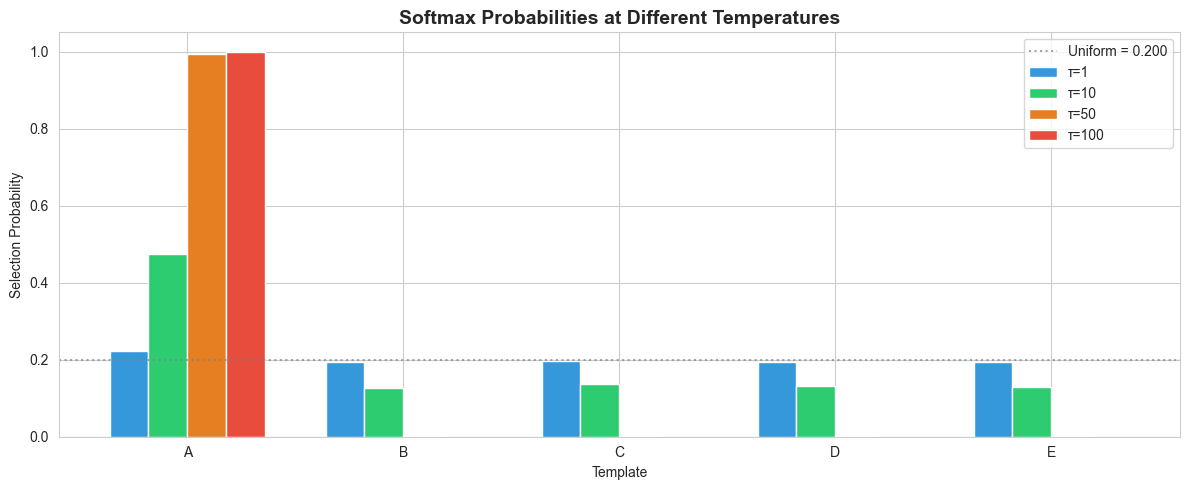

Low τ → nearly uniform (explore everything).
High τ → concentrates on the best (exploit the leader).


In [5]:
# Grouped bar chart
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(demo_templates))
width = 0.18
colors = ["#3498db", "#2ecc71", "#e67e22", "#e74c3c"]

for i, tau in enumerate(tau_values):
    probs = softmax_probabilities(demo_templates, demo_scores, tau)
    prob_vals = [probs[t] for t in demo_templates]
    ax.bar(x + i * width, prob_vals, width, label=f"τ={tau}", color=colors[i], edgecolor="white")

ax.axhline(y=1/len(demo_templates), color="gray", linestyle=":", alpha=0.7,
           label=f"Uniform = {1/len(demo_templates):.3f}")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(demo_templates)
ax.set_title("Softmax Probabilities at Different Temperatures", fontsize=14, fontweight="bold")
ax.set_xlabel("Template")
ax.set_ylabel("Selection Probability")
ax.legend()
plt.tight_layout()
plt.show()

print("Low τ → nearly uniform (explore everything).")
print("High τ → concentrates on the best (exploit the leader).")

---
## 5. Simulation — 1000 Draws at τ=50

Let's sample 1,000 times and see if the empirical distribution matches the theoretical probabilities.

In [6]:
tau = 50
rng = np.random.default_rng(42)

selections = [softmax_select(demo_templates, demo_scores, tau, rng) for _ in range(1000)]
theoretical = softmax_probabilities(demo_templates, demo_scores, tau)

print(f"{'Template':<10} {'Theoretical':>12} {'Empirical':>12} {'Draws':>8}")
print("-" * 44)
for t in demo_templates:
    emp = selections.count(t) / 1000
    print(f"{t:<10} {theoretical[t]:>12.4f} {emp:>12.4f} {selections.count(t):>8}")

Template    Theoretical    Empirical    Draws
--------------------------------------------
A                0.9936       0.9940      994
B                0.0014       0.0010        1
C                0.0020       0.0010        1
D                0.0016       0.0020        2
E                0.0015       0.0020        2


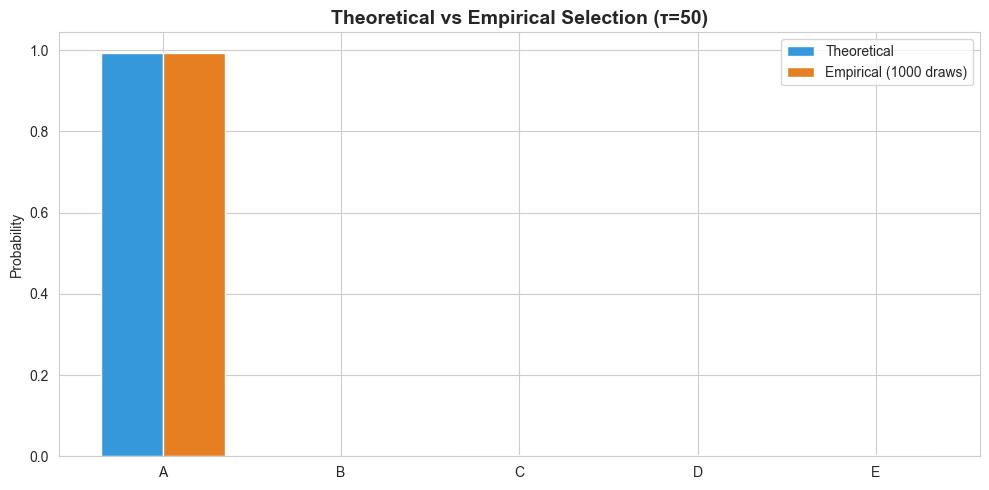

In [7]:
# Side-by-side bar chart
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(demo_templates))
width = 0.35

theo_vals = [theoretical[t] for t in demo_templates]
emp_vals = [selections.count(t) / 1000 for t in demo_templates]

ax.bar(x - width/2, theo_vals, width, label="Theoretical", color="#3498db", edgecolor="white")
ax.bar(x + width/2, emp_vals, width, label="Empirical (1000 draws)", color="#e67e22", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(demo_templates)
ax.set_title(f"Theoretical vs Empirical Selection (τ={tau})", fontsize=14, fontweight="bold")
ax.set_ylabel("Probability")
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Full Single-Event Walkthrough

Let's trace one real event through the entire pipeline: **smoothed scores → recency adjustment → softmax → selection**.

In [8]:
# Load a small sample for the worked example
train_df = load_sample(n_rows=1000, split="train")

# Find a row with non-empty history for a more interesting demo
example_idx = None
for i in range(len(train_df)):
    h = parse_history(train_df["history"].iloc[i])
    elig = train_df["eligible_templates"].iloc[i]
    if isinstance(elig, str):
        import ast
        elig = ast.literal_eval(elig)
    if len(h) >= 2 and len(elig) >= 4:
        example_idx = i
        break

if example_idx is None:
    example_idx = 0

row = train_df.iloc[example_idx]
eligible = row["eligible_templates"]
if isinstance(eligible, str):
    eligible = ast.literal_eval(eligible)
history = parse_history(row["history"])

print(f"Event #{example_idx}")
print(f"  Selected:  {row['selected_template']}")
print(f"  Reward:    {row['session_end_completed']}")
print(f"  Eligible:  {eligible}")
print(f"  History:   {history}")

[data_loader] Found 3 parquet files for 'train' split
[data_loader] === SAMPLE MODE ===
[data_loader] Loading 1,000 rows from 3 file(s)...
  Read part-00000-9b4bba6b-feac-44b1-a155-17c796835cca-c000.snappy.parquet: 1,980,100 rows so far
[data_loader] Raw data loaded: 1,000 rows in 5.2s
[data_loader] Memory (raw): 0.3 MB
[data_loader] Post-processing columns (parsing history & templates)...
[postprocess] Processing 1,000 rows in 1 batch(es) of 1,000,000...
  Batch 1/1: rows 0-1,000 done in 1.1s | Total: 1,000/1,000 (100%) | ETA: 0s
[postprocess] All 1,000 rows processed in 1.1s
[data_loader] Post-processing done in 1.1s
[data_loader] ✓ Final: 1,000 rows loaded in 6.3s total
[data_loader] Columns: ['datetime', 'ui_language', 'eligible_templates', 'history', 'selected_template', 'session_end_completed']
[data_loader] Memory (final): 0.4 MB
Event #0
  Selected:  B
  Reward:    0
  Eligible:  ['G', 'E', 'B', 'A', 'K', 'H', 'J', 'L', 'F', 'D']
  History:   [('A', 28.195648193359375), ('C', 2

In [9]:
# Step 1: Get smoothed scores for eligible templates
print("STEP 1: Smoothed scores (from training)")
eligible_scores = {t: smoothed_scores.get(t, 0.0) for t in eligible}
for t in eligible:
    print(f"  {t}: {eligible_scores[t]:+.6f}")

# Step 2: Apply recency penalty
gamma, h_val = 0.1, 0.5
print(f"\nSTEP 2: Apply recency penalty (γ={gamma}, h={h_val})")
adjusted = adjust_scores_with_recency(eligible_scores, history, gamma, h_val)
for t in eligible:
    diff = adjusted[t] - eligible_scores[t]
    marker = f" (penalty={abs(diff):.6f})" if abs(diff) > 0.00001 else ""
    print(f"  {t}: {eligible_scores[t]:+.6f} → {adjusted[t]:+.6f}{marker}")

# Step 3: Softmax probabilities
tau = 50
print(f"\nSTEP 3: Softmax probabilities (τ={tau})")
probs = explain_softmax_selection(eligible, adjusted, tau)

# Step 4: Sample
print(f"\nSTEP 4: Sample a template")
rng = np.random.default_rng(42)
selected = softmax_select(eligible, adjusted, tau, rng)
print(f"  → Selected: {selected} (probability was {probs[selected]:.4f})")
print(f"  (The actual data chose: {row['selected_template']})")

STEP 1: Smoothed scores (from training)
  G: -0.003868
  E: -0.005923
  B: -0.006921
  A: +0.124412
  K: -0.004072
  H: -0.006920
  J: -0.005097
  L: -0.003776
  F: -0.006545
  D: -0.004490

STEP 2: Apply recency penalty (γ=0.1, h=0.5)
  G: -0.003868 → -0.004250 (penalty=0.000382)
  E: -0.005923 → -0.010841 (penalty=0.004918)
  B: -0.006921 → -0.007058 (penalty=0.000136)
  A: +0.124412 → +0.113853 (penalty=0.010559)
  K: -0.004072 → -0.004072
  H: -0.006920 → -0.009772 (penalty=0.002853)
  J: -0.005097 → -0.005097
  L: -0.003776 → -0.003776
  F: -0.006545 → -0.043309 (penalty=0.036764)
  D: -0.004490 → -0.004490

STEP 3: Softmax probabilities (τ=50)

[softmax] Computing selection probabilities (τ = 50)
[softmax] Eligible templates: ['G', 'E', 'B', 'A', 'K', 'H', 'J', 'L', 'F', 'D']

Template        Score    τ×Score    Shifted        exp()  P(select)
------------------------------------------------------------------------
G           -0.004250    -0.2125    -5.9051       0.0027     0.00

---
## 7. Summary

| Concept | What it does |
|---------|-------------|
| **Softmax** | Converts scores into probabilities using $P(a) \propto e^{\tau \times \text{score}(a)}$ |
| **Temperature (τ)** | Low = explore, High = exploit |
| **Selection** | Sample from the probability distribution |

At this point we have the **complete decision pipeline**: raw rates → RDS → Bayesian smoothing → recency penalty → softmax → selection.

The final question: **does it actually work?** We need to evaluate our policy against the random baseline using offline evaluation.

**Next notebook:** `06_full_pipeline_evaluation.ipynb` — fit the policy, evaluate with importance sampling, measure lift.